<a href="https://colab.research.google.com/github/shaikaalima06-gif/PRODIGY_ML_03/blob/main/prodigy_task03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import requests

# Alternative mirror for the Cats vs Dogs dataset
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
filename = "cats_and_dogs.zip"

if not os.path.exists(filename):
    print("Downloading dataset... this may take a minute.")
    r = requests.get(url, allow_redirects=True)
    with open(filename, 'wb') as f:
        f.write(r.content)
    print("Download complete.")

# Extracting the dataset
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("pet_data")

# Path setup (Microsoft version uses PetImages/Cat and PetImages/Dog)
base_dir = "pet_data/PetImages"
print(f"Dataset extracted to: {base_dir}")
print("Categories found:", os.listdir(base_dir))

Download complete.
Dataset extracted to: pet_data/PetImages
Categories found: ['Dog', 'Cat']


In [5]:
import cv2
import numpy as np

def load_data(data_dir, categories, sample_size=500):
    data = []
    labels = []

    for category in categories:
        # Note: Microsoft uses 'Cat' and 'Dog' (singular)
        category_path = "Cat" if category == 'cats' else "Dog"
        path = os.path.join(data_dir, category_path)
        class_num = categories.index(category)

        count = 0
        for img_name in os.listdir(path):
            if count >= sample_size:
                break
            try:
                img_path = os.path.join(path, img_name)
                # Read grayscale and resize to 64x64
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None: continue # Skip corrupted images

                img = cv2.resize(img, (64, 64))
                data.append(img.flatten())
                labels.append(class_num)
                count += 1
            except Exception:
                continue

    return np.array(data), np.array(labels)

categories = ['cats', 'dogs']
X, y = load_data(base_dir, categories, sample_size=500)

print(f"Loaded {len(X)} images successfully.")

Loaded 1000 images successfully.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVMs require feature scaling to perform well
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split and scaled.")

Data split and scaled.


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Training SVM... (This uses the RBF kernel)")
model = SVC(kernel='rbf', C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Training SVM... (This uses the RBF kernel)
Model Accuracy: 58.00%


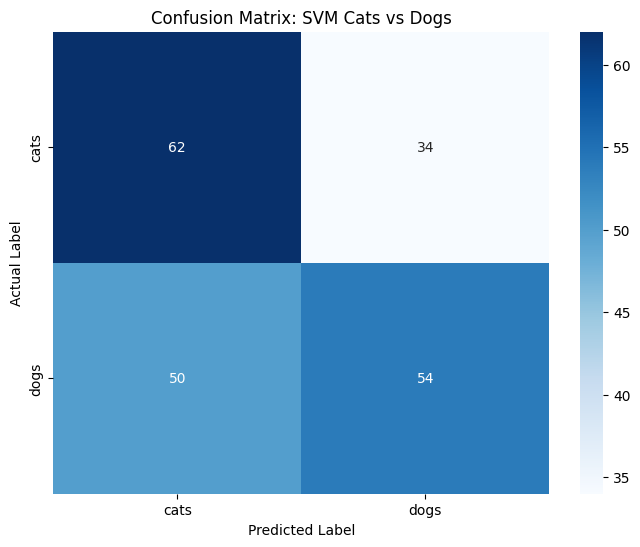


Detailed Classification Report:
              precision    recall  f1-score   support

        cats       0.55      0.65      0.60        96
        dogs       0.61      0.52      0.56       104

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)

plt.title('Confusion Matrix: SVM Cats vs Dogs')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# 3. Print detailed metrics
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=categories))